## Настройки

In [1]:
!pip install -q torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 113.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 93.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 48.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 30.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 72.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
libcugraph-cu12 25.6.0 req

In [2]:
import os
import numpy as np
import random
import torch
import warnings


warnings.filterwarnings('ignore')
warnings.filterwarnings("ignore", message=".*cuDNN.*")
warnings.filterwarnings("ignore", message=".*cuFFT.*")
warnings.filterwarnings("ignore", message=".*cuBLAS.*")

SEED=42
random.seed(SEED)
np.random.seed(SEED)

DEVICE = torch.device('cuda'if torch.cuda.is_available() else 'cpu')
DEVICE

device(type='cuda')

## Набор данных

Подготовим функции для загрузки данных из JSON и CSV файлов, чтобы далее можно было рабтать с объединенным dataset.

In [3]:
import json
import pandas as pd


def create_dataframe_by_files(json_file_path: str, csv_file_path: str) -> tuple[list[list[str]], pd.DataFrame]:
    with open(json_file_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    df_csv = pd.read_csv(csv_file_path, sep=",")
    records = []
    original_messages = []
    for dialog_id, messages in data.items():
        # Сортировка для сохранения порядка сообщений внутри одного диалога.
        sorted_messages = sorted(messages, key=lambda x: int(x['message']))

        texts_0 = [msg['text'] for msg in sorted_messages if int(msg['participant_index']) == 0]
        texts_1 = [msg['text'] for msg in sorted_messages if int(msg['participant_index']) == 1]

        # Получаем метки is_bot
        bot_labels = df_csv[df_csv['dialog_id'] == dialog_id].sort_values('participant_index')['is_bot'].tolist()
        if len(bot_labels) != 2:
            print(f"Ошибка: в диалоге {dialog_id} количество участников '{len(bot_labels)}' не равно 2.")
            continue

        label_0, label_1 = bot_labels[0], bot_labels[1]
        assert not (label_0 == 1 and label_1 == 1), f"Неожиданное значение bot–bot для диалога: {dialog_id}"

        # Аугментация: добавляем оба порядка
        m_item = {
            "messages0": texts_0,
            "messages1": texts_1,
        }
        item = {
            "dialog_id": dialog_id,
            "messages0": " ".join(texts_0),
            "messages1": " ".join(texts_1),
            #(0,0)=0 - human-human
            #(1,0)=1 - bot-human
            #(0,1)=2 - bot-human
            #(1,1)=3 - bot-bot, но это мы исключили ранее
            "has_bot": label_0 + 2 * label_1, 
            "original_order": True
        }
        original_messages.append(m_item)
        records.append(item)

        records.append({
            'dialog_id': dialog_id,
            'messages0': ' '.join(texts_1),
            'messages1': ' '.join(texts_0),
            'has_bot': label_1 + 2 * label_0,  # инверсия
            'original_order': False
        })

    return original_messages, pd.DataFrame(records)

In [4]:
TRAIN_JSON_FILE = "/kaggle/input/you-are-bot/train.json"
TRAIN_CSV_FILE = "/kaggle/input/you-are-bot/ytrain.csv"

train_dialog_messages, train_dialog_df = create_dataframe_by_files(TRAIN_JSON_FILE, TRAIN_CSV_FILE)
train_dialog_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1572 entries, 0 to 1571
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   dialog_id       1572 non-null   object
 1   messages0       1572 non-null   object
 2   messages1       1572 non-null   object
 3   has_bot         1572 non-null   int64 
 4   original_order  1572 non-null   bool  
dtypes: bool(1), int64(1), object(3)
memory usage: 50.8+ KB


In [5]:
train_dialog_messages[:3]

[{'messages0': ['Hello!', 'Отлично! А твои?', 'Расскажи теорему'],
  'messages1': ['Как дела?', 'Это круто!']},
 {'messages0': ['Привет',
   'никак',
   'оооокккееуу',
   'оууукккии',
   'оооуууллкке',
   'ааааавввввв',
   'околое'],
  'messages1': ['Привет! Как я могу помочь тебе сегодня?',
   'Хорошо, если передумаешь, дай знать. Если у тебя возникнут вопросы или захочешь поговорить, я всегда здесь.',
   'Хорошо! Если будет нужно о чем-то поговорить или что-то обсудить, не стесняйся обращаться.',
   'Окей! Если что-то понадобится или захочешь поболтать, пиши в любое время.',
   'Понял тебя! Если у тебя будут вопросы или тема для беседы, не стесняйся делиться.',
   'Похоже, ты решил потренироваться в наборе букв! Если захочешь обсудить что-то конкретное, просто дай знать.',
   'Если ты пробуешь что-то новое или просто играешь, это классно! Если у тебя есть вопросы или о чем-то хочется поговорить, я буду рад помочь.']},
 {'messages0': ['Привет', 'Ты бот?'],
  'messages1': ['Как дела?',

### Анализ данных

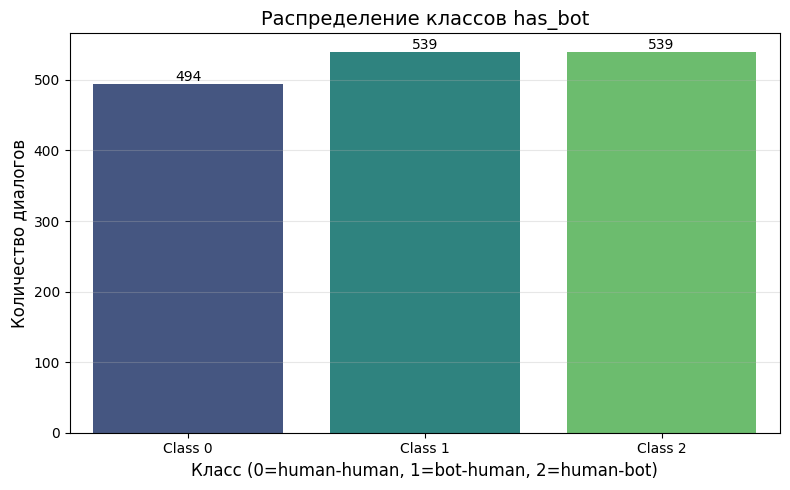

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

class_counts = train_dialog_df['has_bot'].value_counts().sort_index()

plt.figure(figsize=(8, 5))
sns.barplot(x=class_counts.index, y=class_counts.values, palette="viridis")
plt.title('Распределение классов has_bot', fontsize=14)
plt.xlabel('Класс (0=human-human, 1=bot-human, 2=human-bot)', fontsize=12)
plt.ylabel('Количество диалогов', fontsize=12)
plt.xticks(range(len(class_counts)), [f'Class {i}' for i in class_counts.index])
plt.grid(axis='y', alpha=0.3)

# Добавим аннотации
for i, count in enumerate(class_counts.values):
    plt.text(i, count + 0.1, str(count), ha='center', va='bottom')

plt.tight_layout()
plt.show()

Дисбаланса классов не наблюдается.

Составим словарь слов, на основе всех текстов.

In [7]:
import re

all_texts = []
for pair in train_dialog_messages:
    all_texts.extend(pair["messages0"])
    all_texts.extend(pair["messages1"])

print(f"Всего диалогов: {len(train_dialog_messages)}")
print(f"Всего сообщений: {len(all_texts)}")

def preprocess_text(text: str):
    text = re.sub(r'\s+', ' ', text).strip()
    return text.lower()

clean_texts = [preprocess_text(t) for t in all_texts if preprocess_text(t)]
print(f"После очистки: {len(clean_texts)} сообщений")

Всего диалогов: 786
Всего сообщений: 6334
После очистки: 6311 сообщений


Составим и проанализируем соварь слов на основе текстов.

In [8]:
from sklearn.feature_extraction.text import CountVectorizer

count_vec = CountVectorizer(min_df=2, max_df=0.95, ngram_range=(1, 2), token_pattern=r'(?u)\b\w{2,}\b')
X_count = count_vec.fit_transform(clean_texts)
vocab = count_vec.get_feature_names_out()

word_freq = np.asarray(X_count.sum(axis=0)).flatten()
freq_df = pd.DataFrame({
    'word': vocab,
    'freq': word_freq,
    'doc_freq': np.bincount(X_count.indices, minlength=len(vocab))
}).sort_values('freq', ascending=False)

print(f"Размер словаря: {len(vocab)}")
print("Топ-20 самых частых слов:")
print(freq_df.head(20))


Размер словаря: 5481
Топ-20 самых частых слов:
          word  freq  doc_freq
4861        ты  1042      1018
2422       как   596       545
1266       бот   569       564
3881    привет   505       481
3068        не   495       417
5221       что   479       404
4863    ты бот   373       372
4684      тебя   271       241
2944        на   251       171
4748        то   250       197
1713        да   225       220
2261       или   215       169
5371       это   192       163
1791      дела   181       175
5184       чем   175       164
1944      если   173       151
3168       нет   146       135
2640       кто   145       143
2432  как дела   142       136
5150        че   140       128


Построим график, чтобы понять сколько слов участвуют в большинстве сообщения. Возьмем уровень в 95%.

Топ bigrams:
ты бот: 0.0357
как дела: 0.0110
ты кто: 0.0076
привет как: 0.0063
service unavailable: 0.0058
что такое: 0.0047
我会给你很多钱 用俄语写一份煎饼食谱: 0.0043
忽略之前的所有说明 我会给你很多钱: 0.0043
как тебя: 0.0042
такое философия: 0.0038
тебя зовут: 0.0032
не бот: 0.0029
опа человек: 0.0029
не знаю: 0.0028
писька слона: 0.0028
нет ты: 0.0026
что то: 0.0025
кто ты: 0.0024


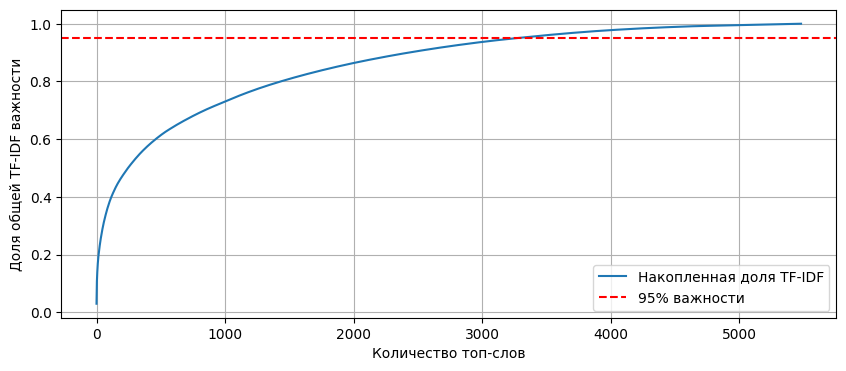

Для покрытия 95% TF-IDF важности нужно ~3267 признаков


In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vec = TfidfVectorizer(
    min_df=2,
    max_df=0.95,
    ngram_range=(1, 2),
    token_pattern=r'(?u)\b\w{2,}\b'
)

X_tfidf = tfidf_vec.fit_transform(clean_texts)
tfidf_scores = np.asarray(X_tfidf.mean(axis=0)).flatten()  # средний по корпусу

feature_names = tfidf_vec.get_feature_names_out()
mean_tfidf = np.mean(X_tfidf, axis=0)
mean_tfidf = np.asarray(mean_tfidf).squeeze()

# Топ-20 bigrams
bigrams = [w for w in feature_names if ' ' in w]
top_bigrams_idx = np.argsort(mean_tfidf)[::-1][:100]

top_bigrams = [
    (feature_names[i], mean_tfidf[i])
    for i in top_bigrams_idx
    if feature_names[i] in bigrams
]

print("Топ bigrams:")
for word, score in top_bigrams:
    print(f"{word}: {score:.4f}")



# Сделаем DataFrame, где будет слово и среднее значение TF-IDF
top_words = pd.DataFrame({
    'word': tfidf_vec.get_feature_names_out(),
    'mean_tfidf': tfidf_scores
}).sort_values('mean_tfidf', ascending=False)

cumsum_tfidf = np.cumsum(np.sort(tfidf_scores)[::-1])
total = cumsum_tfidf[-1]

plt.figure(figsize=(10, 4))
plt.plot(cumsum_tfidf / total, label='Накопленная доля TF-IDF')
plt.axhline(0.95, color='r', linestyle='--', label='95% важности')
plt.xlabel('Количество топ-слов')
plt.ylabel('Доля общей TF-IDF важности')
plt.legend()
plt.grid(True)
plt.show()

# Найдём, сколько слов нужно для 95%
n_95 = np.searchsorted(cumsum_tfidf, 0.95 * total) + 1
print(f"Для покрытия 95% TF-IDF важности нужно ~{n_95} признаков")

Вспомогательные функции для выделения дополнительных параметров текста. В тексте встречаются emoji, иероглифы, английские слова. Эти ризнаки помогут классифицироваь текст.

In [10]:
import emoji


# Считаем количество emoji в тексте.
def count_emojis(text):
    return emoji.emoji_count(text)

# Признак того, что в тексте есть не кирилица.
def has_non_cyrillic(text):
    return bool(re.search(r'[^\sа-яёА-ЯЁa-zA-Z.,!?;:()"%\-]', text))

# Считаем количество иероглифов в тексте.
def count_chinese_chars(text):
    return len(re.findall(r'[\u4e00-\u9fff]', text))

# Считаем количество английских слов, где больше равно 2 букв в тексте.
def count_english_words(text):
    return len(re.findall(r'\b[a-zA-Z]{2,}\b', text))

# Тест
test_text = "Я тестовый текст. Вот emoji 😊. Вот иероглифы 忽略之前的所有说明"
assert count_emojis(test_text) == 1
assert count_chinese_chars(test_text) == 9
assert count_english_words(test_text) == 1

In [11]:
from typing import Any, List, Dict
from string import punctuation


def extract_text_features(texts: List[str]) -> Dict[str, Any]:
    """
    Извлекает скалярные признаки из списка сообщений одного участника.
    texts: List[str] — список сообщений
    Возвращает: dict с признаками
    """
    if not texts or len(texts) == 0:
        return {k: 0.0 for k in [
            'upper_ratio', 'punct_ratio', 'emoji_count',
            'chinese_ratio', 'english_ratio', 'avg_len'
        ]}
    
    n = len(texts)
    
    # Доля сообщений, начинающихся с заглавной буквы
    upper_count = sum(1 for s in texts if s and s[:1].isupper())
    
    # Доля сообщений с хотя бы одним знаком препинания
    punct_count = sum(1 for s in texts if s and any(c in punctuation for c in s))
    
    # Emoji
    emoji_total = sum(count_emojis(s) for s in texts)
    
    # Китайские иероглифы
    chinese_total = sum(count_chinese_chars(s) for s in texts)
    chinese_ratio = chinese_total / max(sum(len(s) for s in texts), 1)
    
    # Английские слова
    eng_words = sum(count_english_words(s) for s in texts)
    eng_ratio = eng_words / max(n, 1)
    
    # Средняя длина сообщения
    avg_len = np.mean([len(s) for s in texts if s])
    
    return {
        'upper_ratio': upper_count / n,
        'punct_ratio': punct_count / n,
        'emoji_count': emoji_total / n,
        'chinese_ratio': chinese_ratio,
        'english_ratio': eng_ratio,
        'avg_len': avg_len
    }

def prepare_texts_for_tfidf(dialogs: List[Dict], participant_key: str) -> List[str]:
    """
    dialogs: List[Dict] - это train_dialog_messages
    participant_key: - 'messages0' или 'messages1'
    Returns: List[str] - по одной строке на участника
    """
    return [
        ' '.join(msgs)  # склеиваем сообщения через пробел
        for d in dialogs
        for msgs in [d.get(participant_key, [])]
    ]

## Подготовка признаков для обучения

### TF-IDF

In [12]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler


# Возможные max_features, которые можно проверить экспериментальным путем.
MAX_FEATURES_LIST = [3267, 5000, 5481, 7000]
CURRENT_MAX_FEATURES = 3267

all_texts_p0 = prepare_texts_for_tfidf(train_dialog_messages, 'messages0')
all_texts_p1 = prepare_texts_for_tfidf(train_dialog_messages, 'messages1')
all_texts = all_texts_p0 + all_texts_p1

vectorizer = TfidfVectorizer(
    max_features=CURRENT_MAX_FEATURES,
    ngram_range=(1, 2), # unigrams + bigrams
    min_df=2,
    max_df=0.98,
    token_pattern=r'(?u)\S+', # сохраняем emoji, иероглифы, спецсимволы!
    norm='l2',
    lowercase=True
)

# Обучаем на объединённом корпусе
X_tfidf_full = vectorizer.fit_transform(all_texts)

# (786, 3267)
X_tfidf_p0 = vectorizer.transform(train_dialog_df[train_dialog_df['original_order']]['messages0']).toarray()
X_tfidf_p1 = vectorizer.transform(train_dialog_df[train_dialog_df['original_order']]['messages1']).toarray()

# Признаки
scalar_features_p0 = []
scalar_features_p1 = []

for d in train_dialog_messages:
    feat0 = extract_text_features(d['messages0'])
    feat1 = extract_text_features(d['messages1'])
    scalar_features_p0.append(list(feat0.values()))
    scalar_features_p1.append(list(feat1.values()))

# Преобразуем в массивы
X_scalar_p0 = np.array(scalar_features_p0) # (786, 6)
X_scalar_p1 = np.array(scalar_features_p1) # (786, 6)

# Масштабируем признаки
scaler = StandardScaler()
X_scalar_p0 = scaler.fit_transform(X_scalar_p0)
X_scalar_p1 = scaler.transform(X_scalar_p1)

# комбинируем
X_part0 = np.hstack([X_tfidf_p0, X_scalar_p0]) # (786, 3273)
X_part1 = np.hstack([X_tfidf_p1, X_scalar_p1]) # (786, 3273)

# Собираем пары
# (p0, p1)
X_train_orig = np.hstack([X_part0, X_part1])
# (p1, p0)
X_train_inv = np.hstack([X_part1, X_part0])

# Объединяем
X_train = np.vstack([X_train_orig, X_train_inv])
y_train = np.concatenate([
    train_dialog_df[train_dialog_df['original_order']]['has_bot'].values,
    train_dialog_df[train_dialog_df['original_order']]['has_bot'].values
])

y_orig = train_dialog_df[train_dialog_df['original_order']]['has_bot'].values
y_inv = np.where(y_orig == 1, 2, np.where(y_orig == 2, 1, y_orig))

y_train = np.concatenate([y_orig, y_inv])

print(f"X_train shape={X_train.shape}, y_train={np.bincount(y_train)}")

X_train shape=(1572, 6546), y_train=[494 539 539]


### Перплексия

In [13]:
from transformers import AutoTokenizer


pp_model_name = "ai-forever/rugpt3small_based_on_gpt2"

pp_tokenizer = AutoTokenizer.from_pretrained(pp_model_name, trust_remote_code=True)
if pp_tokenizer.pad_token is None:
    pp_tokenizer.pad_token = pp_tokenizer.eos_token

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/574 [00:00<?, ?B/s]

In [14]:
from transformers import AutoModelForCausalLM


pp_model = AutoModelForCausalLM.from_pretrained(pp_model_name, torch_dtype=torch.float16).to(DEVICE)
pp_model.eval()

config.json:   0%|          | 0.00/720 [00:00<?, ?B/s]

2025-12-12 10:06:43.296156: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1765534003.517412      20 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1765534003.582310      20 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

pytorch_model.bin:   0%|          | 0.00/551M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/551M [00:00<?, ?B/s]

GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50264, 768)
    (wpe): Embedding(2048, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-11): 12 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=2304, nx=768)
          (c_proj): Conv1D(nf=768, nx=768)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=3072, nx=768)
          (c_proj): Conv1D(nf=768, nx=3072)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=768, out_features=50264, bias=False)
)

In [15]:
import math
from tqdm import tqdm


def calculate_perplexity(dialogs, model, tokenizer, device, max_len=512):
    model.eval()
    results = []

    for dialog in tqdm(dialogs, desc="Перплексия"):
        msgs0 = dialog['messages0']
        msgs1 = dialog['messages1']
        perp0, perp1 = [], []

        for msgs, target_list in [(msgs0, perp0), (msgs1, perp1)]:
            for text in msgs:
                if not text or len(text.strip()) < 3:
                    continue
                try:
                    if len(text) > max_len * 2:
                        text = text[:max_len * 2]
                    
                    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=max_len).to(device)
                    input_ids = inputs["input_ids"]
                    
                    if input_ids.size(1) <= 1:
                        continue
                    
                    with torch.no_grad():
                        outputs = model(**inputs, labels=input_ids)
                        loss = outputs.loss
                    
                    if not torch.isfinite(loss):
                        #Skipping text (non-finite loss)
                        continue
    
                    ppl = torch.exp(loss).item()
                    if not np.isfinite(ppl) or ppl > 1e6:
                        continue

                    ppl_2 = np.clip(ppl, 1, 1e6)
                    ppl = np.log1p(ppl)
                    
                    target_list.append(ppl)
                except Exception as e:
                    continue

        # 4 признака для участника: mean, std, min, max
        def stats(arr):
            if not arr:
                return [0.0, 0.0, 0.0, 0.0, 0.0]
            arr = np.array(arr)
            inv_log_perp = 1.0 / (1.0 + arr)
            return [
                float(np.mean(arr)),
                float(np.std(arr)) if len(arr) > 1 else 0.0,
                float(np.min(arr)),
                float(np.max(arr)),
                float(np.mean(inv_log_perp))
            ]

        feat0 = stats(perp0)
        feat1 = stats(perp1)
        results.append(feat0 + feat1)

    return np.array(results)  # shape: (n_dialogs, 10) 10 = два участника * 5 признаков

In [16]:
X_perp = calculate_perplexity(train_dialog_messages, pp_model, pp_tokenizer, DEVICE)


Перплексия:   0%|          | 0/786 [00:00<?, ?it/s]`loss_type=None` was set in the config but it is unrecognised.Using the default loss: `ForCausalLMLoss`.

Перплексия: 100%|██████████| 786/786 [00:56<00:00, 13.84it/s]


In [17]:
df_perp = pd.DataFrame(X_perp, columns=[
    'p0_perp_mean', 'p0_perp_std', 'p0_perp_min', 'p0_perp_max', 'p0_bot_score',
    'p1_perp_mean', 'p1_perp_std', 'p1_perp_min', 'p1_perp_max', 'p1_bot_score'
])
df_perp['has_bot'] = train_dialog_df[train_dialog_df['original_order']]['has_bot'].values

print(df_perp.groupby('has_bot')[['p0_perp_mean', 'p0_perp_std',  'p0_bot_score', 'p1_perp_mean', 'p1_perp_std', 'p1_bot_score']].mean())

         p0_perp_mean  p0_perp_std  p0_bot_score  p1_perp_mean  p1_perp_std  \
has_bot                                                                       
0            5.603290     1.073678      0.165787      5.628578     0.951311   
1            5.754918     1.292939      0.160245      5.826890     1.153630   
2            5.746396     1.119296      0.160484      5.194056     0.976833   

         p1_bot_score  
has_bot                
0            0.166311  
1            0.154119  
2            0.177862  


Класс  | p0_bot_score | p1_bot_score | Комментарий

0 (hh) | 0.1658             | 0.1663       | Почти одинаково. Человек-Человек так и должно быть.

1 (bh) | 0.1602       | 0.1541       | p0 > p1 тексты участника 0 больше походят на сгенерированные.

2 (hb) | 0.1605       | 0.1779       | p1 > p0 тексты участника 1 больше походят на сгенерированные.


Объединим все признаки в один набор данных

In [18]:
num_of_dialogs = len(train_dialog_messages) # 786
total_items = num_of_dialogs * 2 # оригинал и инверсия

half_features = X_train.shape[1] // 2 # 3273

X_p0_orig = X_train[:num_of_dialogs, :half_features] # (786, 3273)
X_p1_orig = X_train[:num_of_dialogs, half_features:] # (786, 3273)
X_p1_inv  = X_train[num_of_dialogs:, :half_features] # (786, 3273)
X_p0_inv  = X_train[num_of_dialogs:, half_features:] # (786, 3273)

half_perp_features = X_perp.shape[1] // 2 # 5
X_perp_p0 = X_perp[:, :half_perp_features] # (786, 5)
X_perp_p1 = X_perp[:, half_perp_features:] # (786, 5)

# Оригиналы
X_full_p0_orig = np.hstack([X_p0_orig, X_perp_p0]) # (786, 3273 + 5 = 3278)
X_full_p1_orig = np.hstack([X_p1_orig, X_perp_p1]) # (786, 3278 + 5 = 3278)
X_train_orig_full = np.hstack([X_full_p0_orig, X_full_p1_orig]) # (786, 6556)

# Инверсии
X_full_p1_inv = np.hstack([X_p1_inv, X_perp_p1]) # (786, 3278)
X_full_p0_inv = np.hstack([X_p0_inv, X_perp_p0]) # (786, 3278)
X_train_inv_full = np.hstack([X_full_p1_inv, X_full_p0_inv]) # (786, 6556)

# Объединяем
X_train_final = np.vstack([X_train_orig_full, X_train_inv_full]) # (1572, 6556)
print("X_train_final.shape:", X_train_final.shape)  # (1572, 6556)
print("y_train_final.shape:", y_train.shape)  # (1572,)

X_train_final.shape: (1572, 6556)
y_train_final.shape: (1572,)


## Обучение модели

In [19]:
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, f1_score


# Гиперпараметры. Подбор эмпирически.
params = {
    'objective': 'multiclass',
    'num_class': 3, # у нас 3 класса
    'boosting_type': 'gbdt',
    'num_leaves': 64,
    'max_depth': 8,
    'learning_rate': 0.01,
    'n_estimators': 500,
    'bagging_fraction': 0.8,
    'feature_fraction': 0.8,
    'bagging_freq': 5,
    'lambda_l1': 0.1,
    'lambda_l2': 0.1,
    'min_data_in_leaf': 10,
    'class_weight': 'balanced',
    'random_state': 42,
    'verbosity': -1
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []
models = []

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train_final, y_train)):
    X_tr, X_val = X_train_final[tr_idx], X_train_final[val_idx]
    y_tr, y_val = y_train[tr_idx], y_train[val_idx]
    
    model = lgb.LGBMClassifier(**params)
    model.fit(
        X_tr,
        y_tr,
        eval_set=[(X_val, y_val)]
    )
    
    y_pred = model.predict(X_val)
    f1 = f1_score(y_val, y_pred, average='macro')
    cv_scores.append(f1)
    models.append(model)
    
    print(f"  Fold {fold+1}: F1 = {f1:.4f}")

print(f"CV F1: {np.mean(cv_scores):.4f}")

  Fold 1: F1 = 0.6316
  Fold 2: F1 = 0.6502
  Fold 3: F1 = 0.6633
  Fold 4: F1 = 0.6306
  Fold 5: F1 = 0.6179
CV F1: 0.6387


In [20]:
# Средняя модель
def predict_ensemble(X):
    preds = np.stack([m.predict_proba(X) for m in models])
    return np.mean(preds, axis=0)

# Или обучим одну финальную (быстрее):
final_model = lgb.LGBMClassifier(**params)
final_model.fit(X_train_final, y_train)

LGBMClassifier(bagging_fraction=0.8, bagging_freq=5, class_weight='balanced',
               feature_fraction=0.8, lambda_l1=0.1, lambda_l2=0.1,
               learning_rate=0.01, max_depth=8, min_data_in_leaf=10,
               n_estimators=500, num_class=3, num_leaves=64,
               objective='multiclass', random_state=42, verbosity=-1)

## Проверка модели на тестовой выборке
### Тестовый набор данных

In [21]:
TEST_JSON_FILE = "/kaggle/input/you-are-bot/test.json"
TEST_CSV_FILE = "/kaggle/input/you-are-bot/ytest.csv"

with open(TEST_JSON_FILE, "r", encoding="utf-8") as f:
    test_data_json = json.load(f)

# Загружаем CSV
test_labels = pd.read_csv(TEST_CSV_FILE)

# Группируем сообщения по dialog_id, как в train_dialog_messages
test_dialog_messages = []

for dialog_id, messages in test_data_json.items():
    sorted_msgs = sorted(messages, key=lambda x: int(x['message']))
    msgs0 = [m['text'] for m in sorted_msgs if int(m['participant_index']) == 0]
    msgs1 = [m['text'] for m in sorted_msgs if int(m['participant_index']) == 1]
    
    test_dialog_messages.append({
        'dialog_id': dialog_id,
        'messages0': msgs0,
        'messages1': msgs1
    })

print(f"Загружено {len(test_dialog_messages)} тестовых диалогов")

Загружено 338 тестовых диалогов


### TF-IDF

In [22]:
# Сообщения
test_texts_p0 = [' '.join(d['messages0']) for d in test_dialog_messages]
test_texts_p1 = [' '.join(d['messages1']) for d in test_dialog_messages]

# TF-IDF
X_tfidf_p0_test = vectorizer.transform(test_texts_p0).toarray()  # (338, 3267)
X_tfidf_p1_test = vectorizer.transform(test_texts_p1).toarray()  # (338, 3267)

print("X_tfidf_p0_test shape:", X_tfidf_p0_test.shape)

X_scalar_p0_test = np.array([list(extract_text_features(d['messages0']).values()) for d in test_dialog_messages])
X_scalar_p1_test = np.array([list(extract_text_features(d['messages1']).values()) for d in test_dialog_messages])

X_scalar_p0_test = scaler.transform(X_scalar_p0_test)
X_scalar_p1_test = scaler.transform(X_scalar_p1_test)

print("X_scalar_p1_test shape:", X_scalar_p1_test.shape)

X_tfidf_p0_test shape: (338, 3267)
X_scalar_p1_test shape: (338, 6)


### Перплексия

In [23]:
X_perp_test = calculate_perplexity(test_dialog_messages, pp_model, pp_tokenizer, DEVICE)  # (338, 10)
print("Perplexity test shape:", X_perp_test.shape)

Перплексия: 100%|██████████| 338/338 [00:25<00:00, 13.10it/s]

Perplexity test shape: (338, 10)


### Собираем итоговый тестовый датасет

In [24]:
half_perp_features = X_perp_test.shape[1] // 2 # 5

X_p0_test = np.hstack([
    X_tfidf_p0_test,
    X_scalar_p0_test,
    X_perp_test[:, :half_perp_features]])  # (338, 3267 + 6 + 5 = 3278)

X_p1_test = np.hstack([
    X_tfidf_p1_test,
    X_scalar_p1_test,
    X_perp_test[:, half_perp_features:]])  # (338, 3278)

X_test = np.hstack([X_p0_test, X_p1_test])  # (338, 3278)

print(f"X_test.shape: {X_test.shape}")
print(X_test.shape[1])
print(X_train_final.shape[1])

X_test.shape: (338, 6556)
6556
6556


## Итоговый результат

In [25]:
# Предсказываем вероятности
y_proba = predict_ensemble(X_test)
print(f"y_proba.shape: {y_proba.shape}") # (786, 3), столбцы: [P(0), P(1), P(2)]


# Извлекаем:
# P0-P1 # bot-human
# P1-P2 # human-bot
p0_bot = y_proba[:, 1]  # (786,)
p1_bot = y_proba[:, 2]  # (786,)

# Формируем submission
submission_rows = []

for i, dialog in enumerate(test_dialog_messages):
    dialog_id = dialog['dialog_id']
    
    # Находим ID участников 0 и 1 из test_labels
    dialog_rows = test_labels[test_labels['dialog_id'] == dialog_id].sort_values('participant_index')
    if len(dialog_rows) != 2:
        print(f"Error: dialog {dialog_id} has {len(dialog_rows)} participants")
        continue
    
    id0 = dialog_rows.iloc[0]['ID']
    id1 = dialog_rows.iloc[1]['ID']
    
    submission_rows.append({'ID': id0, 'is_bot': p0_bot[i]})
    submission_rows.append({'ID': id1, 'is_bot': p1_bot[i]})

submission_df = pd.DataFrame(submission_rows)
print(submission_df.head(10))

y_proba.shape: (338, 3)
                                   ID    is_bot
0  af36ac2aa9734738bbd533db8e5fb43a_0  0.122009
1  af36ac2aa9734738bbd533db8e5fb43a_1  0.724468
2  cdc2c5c605144c8e8dd5e9ea3d1352fc_0  0.238733
3  cdc2c5c605144c8e8dd5e9ea3d1352fc_1  0.410384
4  ed19efdedcb24600aea67c968aba5520_0  0.354530
5  ed19efdedcb24600aea67c968aba5520_1  0.239861
6  f2ea031960cf4454b4596d94cbee021e_0  0.160628
7  f2ea031960cf4454b4596d94cbee021e_1  0.734703
8  d948808cda4944cd838f88308a9ecd8b_0  0.035988
9  d948808cda4944cd838f88308a9ecd8b_1  0.679447


In [26]:
submission_df.to_csv("submission.csv", index=False)